# Import CSV file by Python 

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================
# STEP 1: APNI DETAILS YAHAN BHARO
# =============================================
DB_USER     = "root"           # MySQL username
DB_PASSWORD = "root"  # MySQL password
DB_HOST     = "localhost"
DB_NAME     = "hr_analysis"
CSV_PATH    = r"dataset/emp_attrition.csv"  # CSV ka path

# =============================================
# STEP 2: DATABASE BANAO (agar nahi bana)
# =============================================
conn = mysql.connector.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD
)
cursor = conn.cursor()
cursor.execute(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}")
print(f"✅ Database '{DB_NAME}' ready!")
conn.close()

# =============================================
# STEP 3: CSV LOAD KARO
# =============================================
df = pd.read_csv(CSV_PATH)
print(f"✅ CSV loaded! Total Rows: {len(df)}, Total Columns: {len(df.columns)}")
print(df.head(2))

# =============================================
# STEP 4: MYSQL MEIN DATA IMPORT KARO
# =============================================
engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

df.to_sql("hr_attrition", con=engine, if_exists="replace", index=False)

print(f"✅ {len(df)} rows successfully imported into MySQL!")  # CSV ka path

# =============================================
# STEP 2: DATABASE BANAO (agar nahi bana)
# =============================================
conn = mysql.connector.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD
)
cursor = conn.cursor()
cursor.execute(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}")
print(f"✅ Database '{DB_NAME}' ready!")
conn.close()

# =============================================
# STEP 3: CSV LOAD KARO
# =============================================
df = pd.read_csv(CSV_PATH)
print(f"✅ CSV loaded! Total Rows: {len(df)}, Total Columns: {len(df.columns)}")
print(df.head(2))

# =============================================
# STEP 4: MYSQL MEIN DATA IMPORT KARO
# =============================================
engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

df.to_sql("hr_attrition", con=engine, if_exists="replace", index=False)

print(f"✅ {len(df)} rows successfully imported into MySQL!")

✅ Database 'hr_analysis' ready!
✅ CSV loaded! Total Rows: 1470, Total Columns: 35
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...                         1            80                 0   
1  ...                         4            80                 1   

   TotalWorkingYears  TrainingTimesLastYear WorkLifeBalance  YearsAtCompany  \
0                  8                      0               1               6   
1                 10                      3               3              10   

  YearsInCu

# Row Data checking

In [25]:
query="""
SELECT * FROM hr_attrition
"""

df=pd.read_sql(query, engine)
print("\nHow many Null values in the dataset: \n",df.isnull().sum())
print("\nHow many Duplicate values in to the dataset: \n", df.duplicated().sum())


How many Null values in the dataset: 
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0


In [3]:
query="""
SELECT * FROM hr_attrition
LIMIT 5
"""

df=pd.read_sql(query, engine)
print(df)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

# Department wise attrition Count

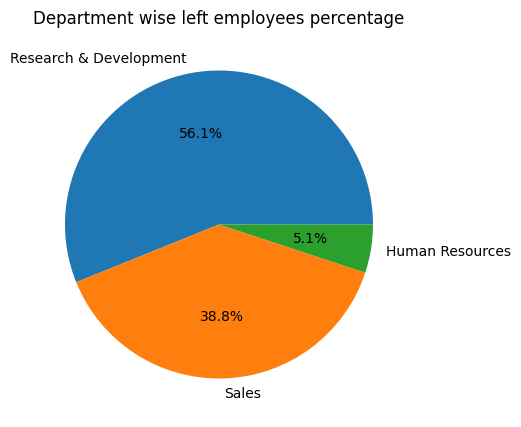

In [38]:
query="""
SELECT 
    department,
    SUM(CASE
        WHEN attrition = 'Yes' THEN 1
        ELSE 0
    END) AS left_emp,
    SUM(CASE
        WHEN attrition = 'No' THEN 1
        ELSE 0
    END) AS active_emp
FROM
    hr_attrition
GROUP BY department
ORDER BY left_emp DESC
"""

df=pd.read_sql(query, engine)

plt.figure(figsize=(5, 5))

plt.pie('left_emp', labels='department', data=df, autopct='%1.1f%%')
plt.title('Department wise left employees percentage')
plt.savefig('department_wise_employee.png')
plt.show()

# Average Salary by Job Roles

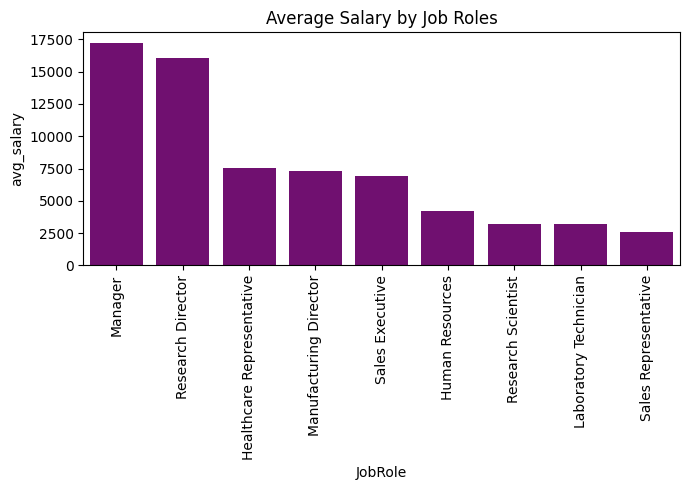

In [39]:
query="""
SELECT 
    JobRole, ROUND(AVG(MonthlyIncome), 2) AS avg_salary
FROM
    hr_attrition
GROUP BY JobRole
ORDER BY avg_salary DESC
"""

df=pd.read_sql(query, engine)

plt.figure(figsize=(7, 5))
sns.barplot(x='JobRole', y='avg_salary', data=df, color='purple')
plt.title('Average Salary by Job Roles')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('average_salary_by_jobrol.png')
plt.show()

# Overtime karne valon ke Attrition Rate 

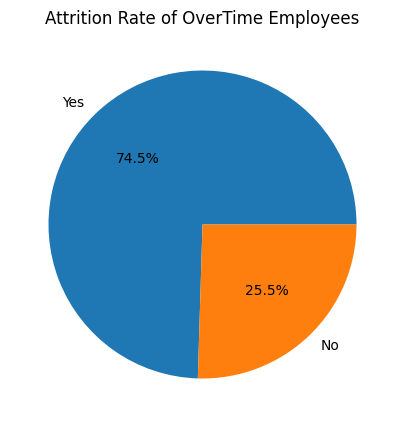

In [40]:
query="""
SELECT 
    OverTime,
    SUM(CASE
        WHEN Attrition = 'Yes' THEN 1
        ELSE 0
    END) AS Left_Employees,
    ROUND(SUM(CASE
                WHEN Attrition = 'Yes' THEN 1
                ELSE 0
            END) * 100.0 / COUNT(*),
            2) AS Attrition_Rate_Percent
FROM
    hr_attrition
GROUP BY OverTime
"""

df=pd.read_sql(query, engine)

plt.figure(figsize=(5,5))
plt.pie('Attrition_Rate_Percent', labels='OverTime', data=df, autopct='%1.1f%%')
plt.title('Attrition Rate of OverTime Employees')
plt.savefig('attrition_rate_of_overtime.png')
plt.show()

# Top 5 JobRoles with highest Attrition

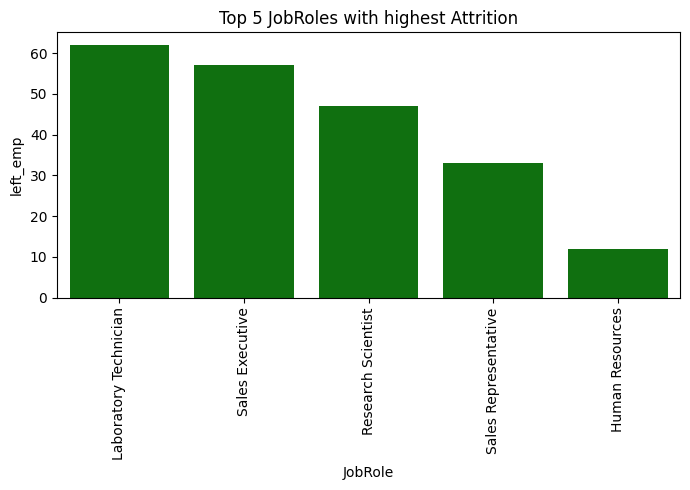

In [41]:
query="""
SELECT 
    JobRole,
    SUM(CASE
        WHEN attrition = 'Yes' THEN 1
        ELSE 0
    END) AS left_emp
FROM
    hr_attrition
GROUP BY JobRole
ORDER BY left_emp DESC
LIMIT 5
"""

df=pd.read_sql(query, engine)

plt.figure(figsize=(7, 5))
sns.barplot(x='JobRole', y='left_emp', data=df, color='green')
plt.title('Top 5 JobRoles with highest Attrition')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('top_5_jobrols_with_highest_attrition.png')
plt.show()

# Age vs Attrition visualization

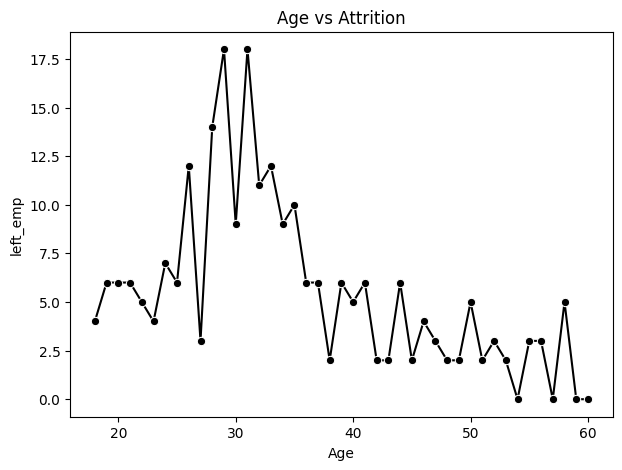

In [42]:
query="""
SELECT 
    Age,
    SUM(CASE
        WHEN Attrition = 'Yes' THEN 1
        ELSE 0
    END) AS left_emp
FROM
    hr_attrition
GROUP BY Age
ORDER BY left_emp DESC
"""

df=pd.read_sql(query, engine)

plt.figure(figsize=(7, 5))
sns.lineplot(x='Age', y='left_emp', data=df, color='black', marker='o')
plt.title('Age vs Attrition')
plt.savefig('age_vs_attrition.png')
plt.show()

# Income vs Attrition

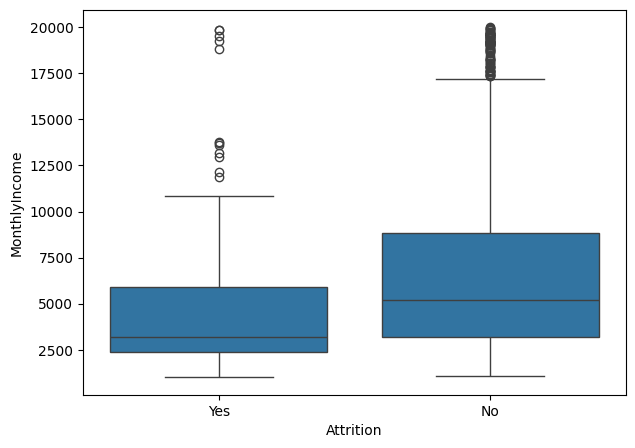

In [2]:
query = """
SELECT MonthlyIncome, Attrition
FROM hr_attrition
"""

df = pd.read_sql(query, engine)

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.savefig('monthlyIncome_vs_attrition.png')
plt.show()